# PlantVillage — Data Pipeline + ResNet-18 Backbone

## 1. Imports & config

In [1]:
%matplotlib inline
import copy
import json
import random
import time
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import resnet18
from huggingface_hub import hf_hub_download
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

REPO_ID = "mohanty/PlantVillage"
CONFIGS = ["color", "grayscale", "segmented"]
IMG_SIZE = 224
VAL_FRACTION = 0.15
BATCH_SIZE = 128
NUM_WORKERS = 0
EPOCHS = 5
LR = 0.05
PRETRAINED = False

CLASS_NAMES = [
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___Powdery_mildew", "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___healthy", "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)", "Peach___Bacterial_spot", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight", "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot", "Tomato___Spider_mites Two-spotted_spider_mite", "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy",
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    try:
        import torch_directml
        if torch_directml.is_available():
            return torch_directml.device()
    except Exception:
        pass
    return torch.device("cpu")


device = pick_device()
print("device:", device, "| classes:", NUM_CLASSES)

device: privateuseone:0 | classes: 38


## 2. Download & extract data

In [2]:
DATA_ROOT = Path.home() / ".cache" / "plantvillage"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
extract_dir = DATA_ROOT / "extracted"
done_marker = extract_dir / ".extracted"

zip_path = hf_hub_download(REPO_ID, "data.zip", repo_type="dataset")
print("data.zip:", zip_path)

if not done_marker.exists():
    print("Extracting (~2.2 GB, one-time) ...")
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)
    done_marker.write_text("ok")
    print("done.")
else:
    print("Already extracted.")

IMAGES_BASE = extract_dir
assert (IMAGES_BASE / "raw").is_dir(), f"Expected 'raw/' under {IMAGES_BASE}."
print("images base:", IMAGES_BASE)

data.zip: C:\Users\Josh Hall\.cache\huggingface\hub\datasets--mohanty--PlantVillage\snapshots\9e97599868962bd0079b8db4b7f1efa9185fa1e7\data.zip
Already extracted.
images base: C:\Users\Josh Hall\.cache\plantvillage\extracted


## 3. Load split lists, leaf map & helpers

In [3]:
split_files = {}
for cfg in CONFIGS:
    for sp in ("train", "test"):
        split_files[(cfg, sp)] = hf_hub_download(REPO_ID, f"splits/{cfg}_{sp}.txt", repo_type="dataset")
leaf_map_path = hf_hub_download(REPO_ID, "leaf_grouping/leaf-map.json", repo_type="dataset")
with open(leaf_map_path, encoding="utf-8") as f:
    LEAF_MAP = json.load(f)


def read_split(cfg, sp):
    with open(split_files[(cfg, sp)], encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]


def class_of(rel_path):
    return rel_path.split("/")[2]


def label_of(rel_path):
    return CLASS_TO_IDX[class_of(rel_path)]


def derive_leaf_id(rel_path):
    parts = rel_path.split("/")
    class_name, file_name = parts[2], parts[3]
    ident = file_name.replace("_final_masked", "")
    if "___" in ident:
        ident = ident.split("___")[-1]
    ident = ident.split("copy")[0]
    for ext in (".jpg", ".JPG", ".png", ".PNG"):
        ident = ident.replace(ext, "")
    ident = ident.strip()
    key = ident.lower()
    suggestions = LEAF_MAP.get(key)
    if suggestions:
        if len(suggestions) == 1:
            return suggestions[0]
        for s in suggestions:
            if class_name in s:
                return s
    return f"fallback_{ident}"


for cfg in CONFIGS:
    print(f"{cfg:10s} train={len(read_split(cfg, 'train')):6d}  test={len(read_split(cfg, 'test')):6d}")

color      train= 43596  test= 10709
grayscale  train= 43203  test= 11102
segmented  train= 42984  test= 11322


## 4. EDA & class-imbalance audit

In [4]:
color_train = read_split("color", "train")
color_test = read_split("color", "test")
train_labels = np.array([label_of(p) for p in color_train])

cnt_vals = np.array([0] * NUM_CLASSES)
for lab, c in Counter(train_labels.tolist()).items():
    cnt_vals[lab] = c
counts_sorted = sorted(((CLASS_NAMES[i], int(cnt_vals[i])) for i in range(NUM_CLASSES)), key=lambda x: x[1])

print(f"Train images: {len(color_train)} | Test images: {len(color_test)}")
print(f"Largest class: {cnt_vals.max()} | Smallest class: {cnt_vals.min()} | "
      f"Imbalance ratio: {cnt_vals.max() / cnt_vals.min():.1f}x")
print("\n5 rarest classes:")
for name, c in counts_sorted[:5]:
    print(f"  {c:5d}  {name}")
print("5 largest classes:")
for name, c in counts_sorted[-5:]:
    print(f"  {c:5d}  {name}")

Train images: 43596 | Test images: 10709
Largest class: 4527 | Smallest class: 120 | Imbalance ratio: 37.7x

5 rarest classes:
    120  Potato___healthy
    209  Raspberry___healthy
    223  Apple___Cedar_apple_rust
    289  Peach___healthy
    307  Tomato___Tomato_mosaic_virus
5 largest classes:
   1691  Tomato___Bacterial_spot
   1755  Peach___Bacterial_spot
   4117  Soybean___healthy
   4257  Tomato___Tomato_Yellow_Leaf_Curl_Virus
   4527  Orange___Haunglongbing_(Citrus_greening)


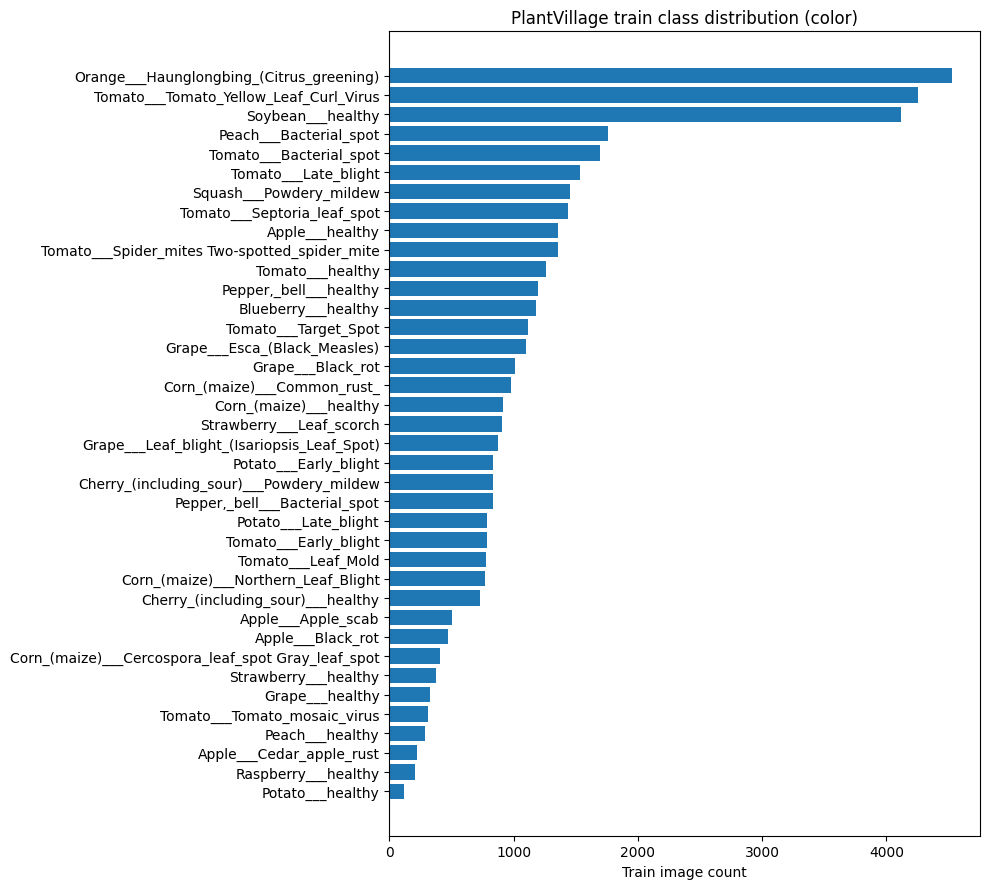

In [5]:
order = np.argsort(cnt_vals)
plt.figure(figsize=(10, 9))
plt.barh([CLASS_NAMES[i] for i in order], cnt_vals[order])
plt.xlabel("Train image count")
plt.title("PlantVillage train class distribution (color)")
plt.tight_layout()
plt.show()

In [6]:
crop_counts = Counter(class_of(p).split("___")[0] for p in color_train)
print("Images per crop (train):")
for crop, c in sorted(crop_counts.items(), key=lambda x: -x[1]):
    print(f"  {c:6d}  {crop}")

Images per crop (train):
   14521  Tomato
    4527  Orange
    4117  Soybean
    3306  Grape
    3058  Corn_(maize)
    2560  Apple
    2044  Peach
    2026  Pepper,_bell
    1744  Potato
    1564  Cherry_(including_sour)
    1457  Squash
    1285  Strawberry
    1178  Blueberry
     209  Raspberry


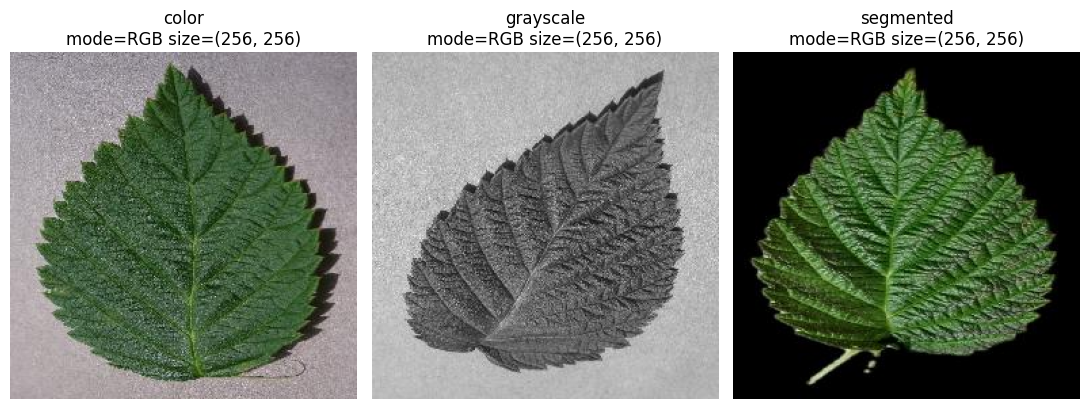

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, cfg in zip(axes, CONFIGS):
    rel = read_split(cfg, "train")[0]
    img = Image.open(IMAGES_BASE / rel)
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(f"{cfg}\nmode={img.mode} size={img.size}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Build train / val / test splits

In [8]:
leaf_ids = np.array([derive_leaf_id(p) for p in color_train])

n_splits = max(2, round(1 / VAL_FRACTION))
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(np.zeros(len(train_labels)), train_labels, groups=leaf_ids))

train_leaf_ids = set(leaf_ids[train_idx].tolist())
val_leaf_ids = set(leaf_ids[val_idx].tolist())

print(f"color train rows: {len(train_idx)} | val rows: {len(val_idx)} "
      f"({len(val_idx) / len(train_labels) * 100:.1f}% of train)")
assert val_leaf_ids.isdisjoint(train_leaf_ids), "leaf overlap between train and val!"
print("No leaf overlap between train and val ✓")

color train rows: 37305 | val rows: 6291 (14.4% of train)
No leaf overlap between train and val ✓


In [9]:
splits = {}
for cfg in CONFIGS:
    files = read_split(cfg, "train")
    lids = np.array([derive_leaf_id(p) for p in files])
    val_mask = np.isin(lids, list(val_leaf_ids))
    splits[cfg] = {
        "train": [f for f, m in zip(files, val_mask) if not m],
        "val": [f for f, m in zip(files, val_mask) if m],
        "test": read_split(cfg, "test"),
    }
    s = splits[cfg]
    print(f"{cfg:10s} train={len(s['train']):6d} val={len(s['val']):6d} test={len(s['test']):6d}")

color      train= 37305 val=  6291 test= 10709
grayscale  train= 38124 val=  5079 test= 11102
segmented  train= 37910 val=  5074 test= 11322


## 6. Imbalance handling — balanced class weights

In [10]:
train_labels_sub = np.array([label_of(p) for p in splits["color"]["train"]])
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels_sub
)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print(f"class weight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

class weight range: 0.254 - 9.440


## 7. PyTorch `Dataset`, transforms & `DataLoader`s

In [11]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    # TODO (optimization step): RandomRotation, ColorJitter, etc.
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


class PlantDataset(Dataset):
    def __init__(self, base, rel_files, tf):
        self.base = Path(base)
        self.files = list(rel_files)
        self.tf = tf

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        rel = self.files[i]
        img = Image.open(self.base / rel).convert("RGB")
        return self.tf(img), CLASS_TO_IDX[class_of(rel)]

In [12]:
ACTIVE_CONFIG = "color"
sp = splits[ACTIVE_CONFIG]

train_ds = PlantDataset(IMAGES_BASE, sp["train"], train_tf)
val_ds = PlantDataset(IMAGES_BASE, sp["val"], eval_tf)
test_ds = PlantDataset(IMAGES_BASE, sp["test"], eval_tf)

pin = device.type == "cuda"
persist = NUM_WORKERS > 0
loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **loader_kw)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
print(f"active config: {ACTIVE_CONFIG} | batch_size={BATCH_SIZE} | num_workers={NUM_WORKERS}")
print(f"batches  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

active config: color | batch_size=128 | num_workers=0
batches  train=292  val=50  test=84


## 8. Model — plug-and-play ResNet-18

In [13]:
def build_model(num_classes=NUM_CLASSES, pretrained=PRETRAINED):
    weights = "IMAGENET1K_V1" if pretrained else None
    m = resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


model = build_model().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet-18 | params: {n_params / 1e6:.1f}M | pretrained={PRETRAINED}")

ResNet-18 | params: 11.2M | pretrained=False


## 9. Training / evaluation scaffolding

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


def train_one_epoch(model, loader, optimizer, criterion, device, max_batches=None, log_every=None):
    model.train()
    running, n = 0.0, 0
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0); n += x.size(0)
        if log_every and (b + 1) % log_every == 0:
            print(f"    batch {b + 1}/{len(loader)}  running_loss {running / n:.4f}", flush=True)
    return running / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    running, n = 0.0, 0
    preds, gts = [], []
    for b, (x, y) in enumerate(loader):
        if max_batches is not None and b >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        out = model(x)
        running += criterion(out, y).item() * x.size(0); n += x.size(0)
        preds.append(out.argmax(1).cpu().numpy())
        gts.append(y.cpu().numpy())
    preds, gts = np.concatenate(preds), np.concatenate(gts)
    return {
        "loss": running / max(n, 1),
        "accuracy": accuracy_score(gts, preds),
        "macro_f1": f1_score(gts, preds, average="macro", zero_division=0),
        "y_true": gts,
        "y_pred": preds,
    }

## 10. Train the baseline (GPU)

In [15]:
baseline = build_model().to(device)
optimizer = torch.optim.SGD(
    baseline.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ckpt_dir = Path("outputs"); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / f"resnet18_{ACTIVE_CONFIG}_best.pt"

best_f1, best_state, history = -1.0, None, []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_one_epoch(baseline, train_loader, optimizer, criterion, device, log_every=50)
    scheduler.step()
    val = evaluate(baseline, val_loader, criterion, device)
    history.append((epoch, tr_loss, val["loss"], val["accuracy"], val["macro_f1"]))
    print(f"epoch {epoch:2d}/{EPOCHS} | train_loss {tr_loss:.4f} | "
          f"val_loss {val['loss']:.4f}  acc {val['accuracy']:.4f}  macroF1 {val['macro_f1']:.4f} "
          f"| {time.time() - t0:.0f}s")
    if val["macro_f1"] > best_f1:
        best_f1 = val["macro_f1"]
        best_state = copy.deepcopy(baseline.state_dict())
        torch.save(best_state, ckpt_path)

print(f"\nbest val macro-F1: {best_f1:.4f}  ->  saved to {ckpt_path}")

    batch 50/292  running_loss 2.8236
    batch 100/292  running_loss 2.2071
    batch 150/292  running_loss 1.8739
    batch 200/292  running_loss 1.6559
    batch 250/292  running_loss 1.4963
epoch  1/5 | train_loss 1.3868 | val_loss 0.9843  acc 0.7102  macroF1 0.6652 | 1904s
    batch 50/292  running_loss 0.6706
    batch 100/292  running_loss 0.6580
    batch 150/292  running_loss 0.6075
    batch 200/292  running_loss 0.5694
    batch 250/292  running_loss 0.5397
epoch  2/5 | train_loss 0.5204 | val_loss 0.8131  acc 0.7525  macroF1 0.7134 | 1908s
    batch 50/292  running_loss 0.3220
    batch 100/292  running_loss 0.2971
    batch 150/292  running_loss 0.2821
    batch 200/292  running_loss 0.2730
    batch 250/292  running_loss 0.2639
epoch  3/5 | train_loss 0.2635 | val_loss 0.4487  acc 0.8488  macroF1 0.8269 | 1919s
    batch 50/292  running_loss 0.1960
    batch 100/292  running_loss 0.1737
    batch 150/292  running_loss 0.1606
    batch 200/292  running_loss 0.1556
    batc

TEST  loss 0.1158  accuracy 0.9630  macro_f1 0.9539

Per-class report (precision / recall / F1):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.93      0.93       127
                                 Apple___Black_rot       0.99      0.97      0.98       146
                          Apple___Cedar_apple_rust       0.98      1.00      0.99        52
                                   Apple___healthy       0.97      0.95      0.96       286
                               Blueberry___healthy       0.94      0.99      0.97       324
          Cherry_(including_sour)___Powdery_mildew       0.98      1.00      0.99       219
                 Cherry_(including_sour)___healthy       0.92      1.00      0.96       123
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.93      0.87       107
                       Corn_(maize)___Common_rust_       1.00      1.00   

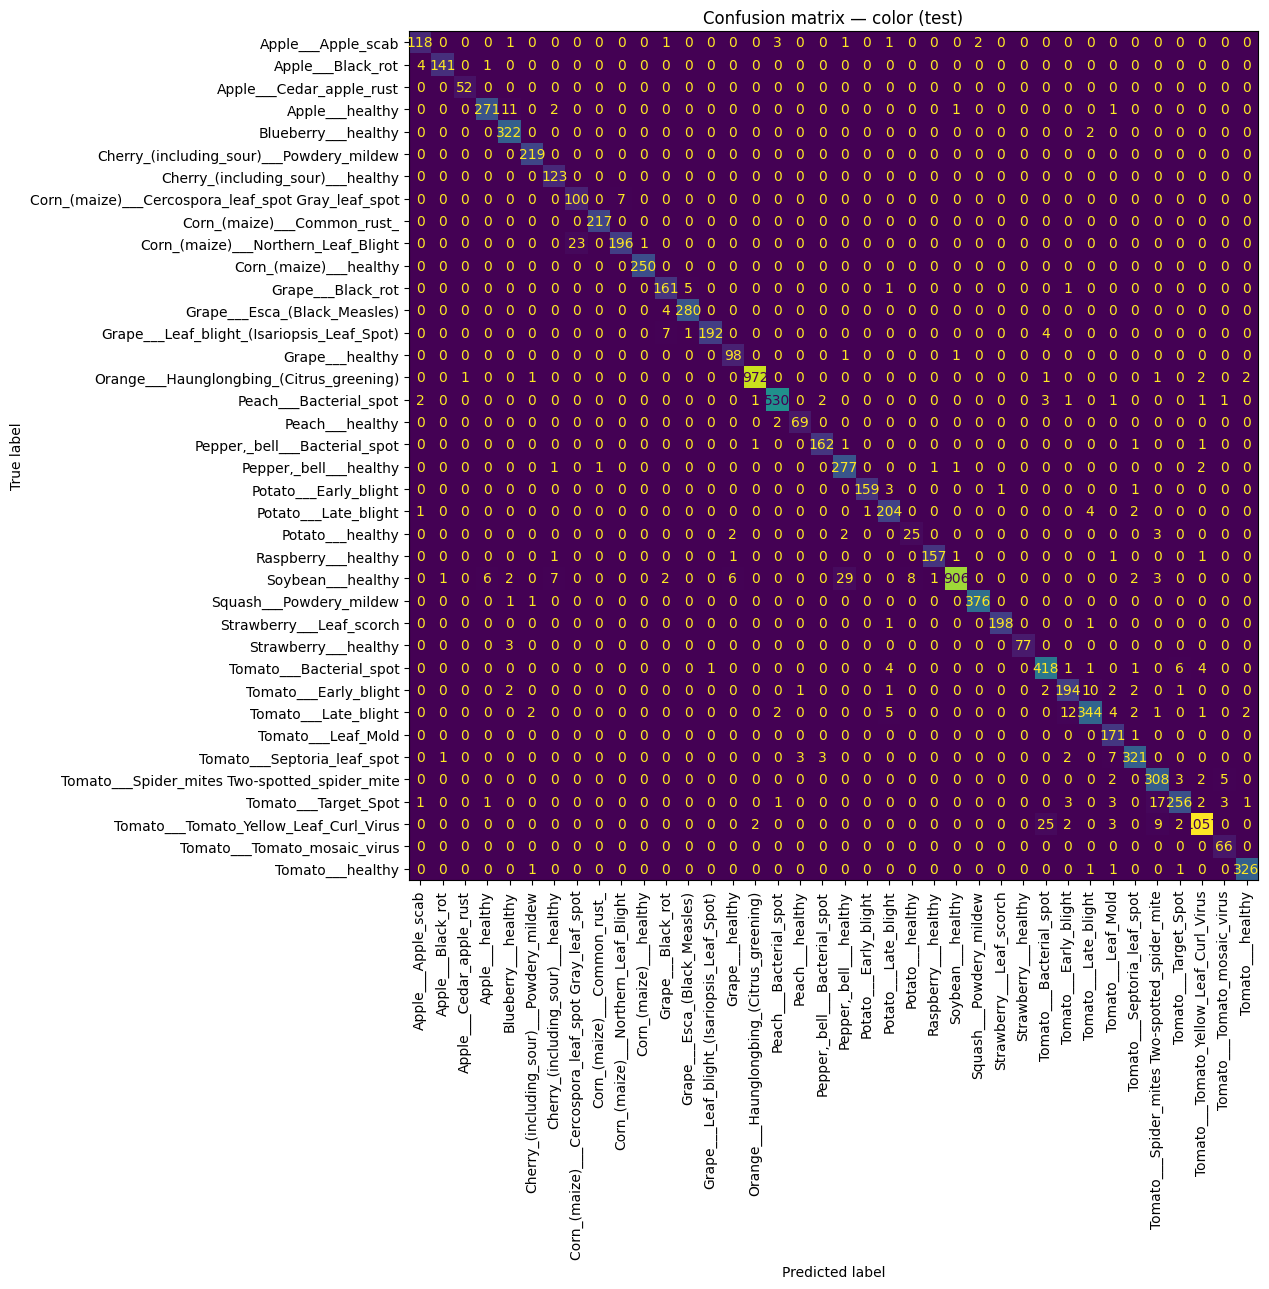

In [16]:
baseline.load_state_dict(best_state)
test = evaluate(baseline, test_loader, criterion, device)
print(f"TEST  loss {test['loss']:.4f}  accuracy {test['accuracy']:.4f}  macro_f1 {test['macro_f1']:.4f}")

print("\nPer-class report (precision / recall / F1):")
print(classification_report(test["y_true"], test["y_pred"],
                            target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(test["y_true"], test["y_pred"])
fig, ax = plt.subplots(figsize=(13, 13))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, xticks_rotation="vertical", colorbar=False)
ax.set_title(f"Confusion matrix — {ACTIVE_CONFIG} (test)")
plt.tight_layout()
plt.show()

## 11. Summary & next steps